# 02 — Tokenisation Examples

Shows how each cell becomes a token sequence under the three schemes:
- **Rank-only** — markers ordered by within-cell expression rank
- **Strength-only** — `marker_BIN` tokens (LOW/MED/HIGH)
- **Hybrid** — interleaved rank-position + strength tokens

**Loading priority:**
1. Pre-processed file `data/levine32_processed.h5ad` (run `prepare_data.py` once).
2. PyCytoData raw load + on-the-fly preprocessing.

In [1]:
import sys
from pathlib import Path
from collections import Counter

PROJECT_ROOT = Path('..').resolve()   # MambaC2S/
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import matplotlib.pyplot as plt

from src.data.loader import load_levine32, load_processed
from src.data.preprocessing import preprocess_from_config
from src.data.tokenization import tokenize_cells, tokenize_single_cell
from src.data.vocab import Vocabulary
from src.utils.config import load_config

%matplotlib inline
plt.rcParams['figure.dpi'] = 100

In [2]:
cfg = load_config(PROJECT_ROOT / 'configs' / 'base.yaml')

DATA_DIR     = PROJECT_ROOT / cfg['dataset']['data_dir']
DATASET_NAME = cfg['dataset']['dataset_name']
LABEL_COL    = cfg['dataset']['label_col']
PREP_CFG     = cfg['preprocessing']
BINS         = PREP_CFG['bins']

## Load Data

In [3]:
processed_path = DATA_DIR / f'{DATASET_NAME}_processed.h5ad'

if processed_path.exists():
    print(f'Loading pre-processed data from {processed_path} ...')
    df = load_processed(processed_path, label_col=LABEL_COL)
else:
    print('Pre-processed file not found — loading via PyCytoData ...')
    df_raw = load_levine32(force_download=True)
    df, _  = preprocess_from_config(df_raw, PREP_CFG)

print(f'Loaded {len(df):,} cells, {len(df.columns)} columns')

Pre-processed file not found — loading via PyCytoData ...


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/PyCytoData/data.py:15: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/fcsparser/api.py:490: UserWarning: The default channel names (defined by the $PnS parameter in the FCS file) were not unique. To avoid problems in downstream analysis, the channel names have been switched to the alternate channel names defined in the FCS file. To avoid seeing this warning message, explicitly instruct the FCS parser to use the alternate channel names by specifying the channel_naming parameter.
  warnings.warn(msg)


Loaded 265,627 cells, 98 columns


## Identify Base Marker Columns

In [4]:
non_marker = {LABEL_COL, 'cell_id'}
marker_cols = [
    c for c in df.columns
    if c not in non_marker
    and not c.endswith('_rank')
    and not c.endswith('_bin')
]
print(f'Markers ({len(marker_cols)}): {marker_cols}')

Markers (32): ['CD45RA', 'CD133', 'CD19', 'CD22', 'CD11b', 'CD4', 'CD8', 'CD34', 'Flt3', 'CD20', 'CXCR4', 'CD235ab', 'CD45', 'CD123', 'CD321', 'CD14', 'CD33', 'CD47', 'CD11c', 'CD7', 'CD15', 'CD16', 'CD44', 'CD38', 'CD13', 'CD3', 'CD61', 'CD117', 'CD49d', 'HLA-DR', 'CD64', 'CD41']


## Single-Cell Tokenisation Example

In [5]:
# Pick one labeled cell for demonstration
row = df[df[LABEL_COL].notna()].iloc[0]

print(f'Cell ID : {row["cell_id"]}')
print(f'Label   : {row[LABEL_COL]}')
print(f'\nFirst 5 markers — value / rank / bin:')
for m in marker_cols[:5]:
    print(f'  {m:20s}  {row[m]:+.4f}  rank={row[f"{m}_rank"]:2d}  bin={row[f"{m}_bin"]}')

Cell ID : cell_0
Label   : Basophils

First 5 markers — value / rank / bin:
  CD45RA                -0.8626  rank= 4  bin=LOW
  CD133                 -0.6771  rank= 8  bin=LOW
  CD19                  -0.6018  rank=13  bin=MED
  CD22                  -0.4342  rank=17  bin=MED
  CD11b                 -0.7114  rank= 6  bin=LOW


In [6]:
# tokenize_single_cell requires the full preprocessed row (with _rank/_bin columns)
for scheme in ('rank_only', 'strength_only', 'hybrid'):
    tokens = tokenize_single_cell(row, marker_cols=marker_cols, scheme=scheme)
    preview = ' '.join(tokens[:16]) + (' ...' if len(tokens) > 16 else '')
    print(f'\n{scheme.upper()} ({len(tokens)} tokens):')
    print(f'  {preview}')


RANK_ONLY (34 tokens):
  <BOS> CD321 CD235ab CD3 CD45 CD45RA CD15 CD11b CD11c CD133 CD7 CD13 CD44 CD64 CD19 CD34 ...

STRENGTH_ONLY (34 tokens):
  <BOS> CD321_LOW CD235ab_LOW CD3_LOW CD45_LOW CD45RA_LOW CD15_LOW CD11b_LOW CD11c_LOW CD133_LOW CD7_LOW CD13_LOW CD44_LOW CD64_LOW CD19_MED CD34_LOW ...

HYBRID (66 tokens):
  <BOS> CD321_R1 CD321_LOW CD235ab_R2 CD235ab_LOW CD3_R3 CD3_LOW CD45_R4 CD45_LOW CD45RA_R5 CD45RA_LOW CD15_R6 CD15_LOW CD11b_R7 CD11b_LOW CD11c_R8 ...


## Vocabulary Statistics (sample of 1,000 cells)

In [7]:
sample_df = df.sample(min(1000, len(df)), random_state=42)

print(f'{"Scheme":20s}  {"Vocab size":>10}  {"Avg seq len":>12}')
print('-' * 46)
for scheme in ('rank_only', 'strength_only', 'hybrid'):
    seqs = tokenize_cells(sample_df, scheme=scheme)
    vocab = Vocabulary()
    vocab.build(seqs)
    avg_len = sum(len(s) for s in seqs) / len(seqs)
    print(f'{scheme:20s}  {len(vocab):>10d}  {avg_len:>12.1f}')

Scheme                Vocab size   Avg seq len
----------------------------------------------
rank_only                     36          34.0
strength_only                100          34.0
hybrid                      1092          66.0


## Sequence Length Distribution

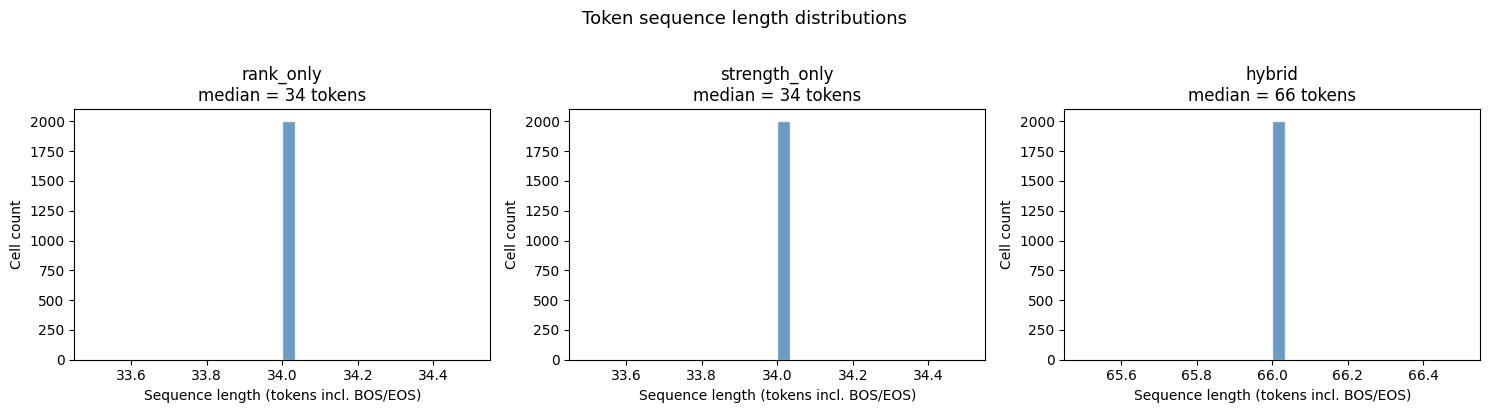

In [8]:
sample_df = df.sample(min(2000, len(df)), random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, scheme in zip(axes, ('rank_only', 'strength_only', 'hybrid')):
    seqs    = tokenize_cells(sample_df, scheme=scheme)
    lengths = [len(s) for s in seqs]
    med     = sorted(lengths)[len(lengths) // 2]
    ax.hist(lengths, bins=30, color='steelblue', alpha=0.8, edgecolor='white')
    ax.set_title(f'{scheme}\nmedian = {med} tokens')
    ax.set_xlabel('Sequence length (tokens incl. BOS/EOS)')
    ax.set_ylabel('Cell count')

plt.suptitle('Token sequence length distributions', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

## Token Frequency — Rank-only Scheme

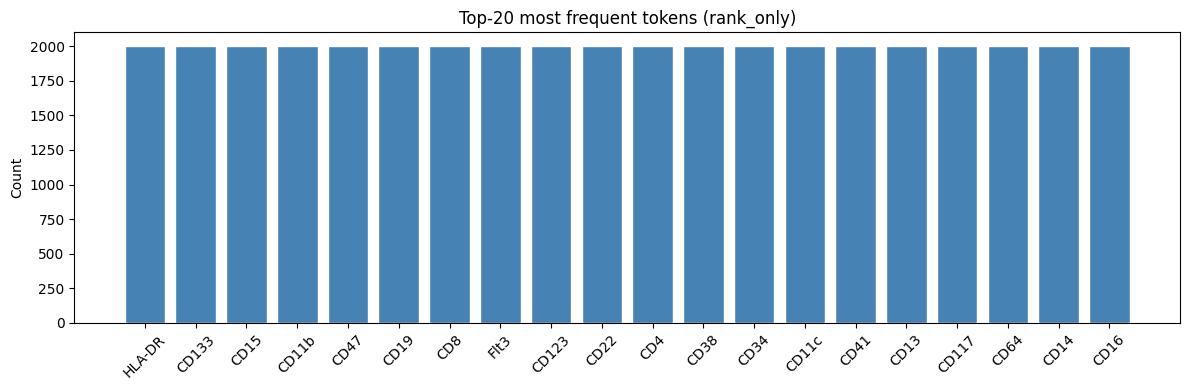

In [9]:
seqs    = tokenize_cells(sample_df, scheme='rank_only')
counter = Counter(
    t for seq in seqs for t in seq if not t.startswith('<')
)

top_n = 20
tokens, freqs = zip(*counter.most_common(top_n))

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(tokens, freqs, color='steelblue', edgecolor='white')
ax.set_title(f'Top-{top_n} most frequent tokens (rank_only)')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()